MIT License

Copyright © 2023-2025 Tohoku University

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

In [1]:
from qklearn.svm import SVC as QSVC
from sklearn.svm import SVC as SSVC
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

Note: Please place `amplify-license.yaml` in the same directory as this notebook in advance.

In [ ]:
from amplify import FixstarsClient
from datetime import timedelta
from qklearn.utils import read_token

client = FixstarsClient()
client.token = read_token("Fixstars")
client.parameters.timeout = timedelta(milliseconds=1000)

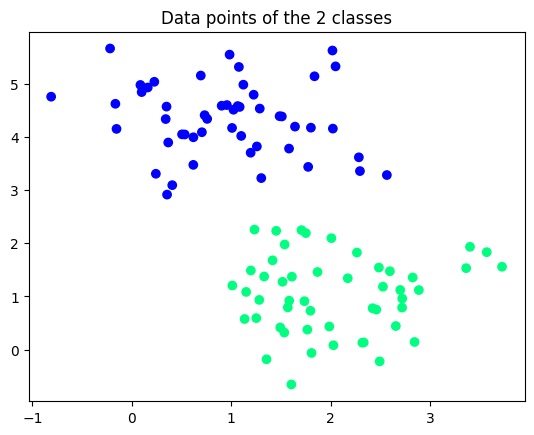

In [3]:
inputs,targets=make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.7)
targets[targets == 0] = -1
plt.scatter(inputs[:,0],inputs[:,1],c=targets, cmap='winter')
plt.title('Data points of the 2 classes')
plt.show()

In [4]:
X_train, X_test, t_train, t_test = train_test_split(inputs,targets)

In [5]:
ssvc = SSVC()
ssvc.fit(X_train, t_train)

y_train_pred_slr = ssvc.predict(X_train)
y_test_pred_slr = ssvc.predict(X_test)

# http://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
acc_sc = accuracy_score(t_test, y_test_pred_slr)
print(acc_sc)

1.0


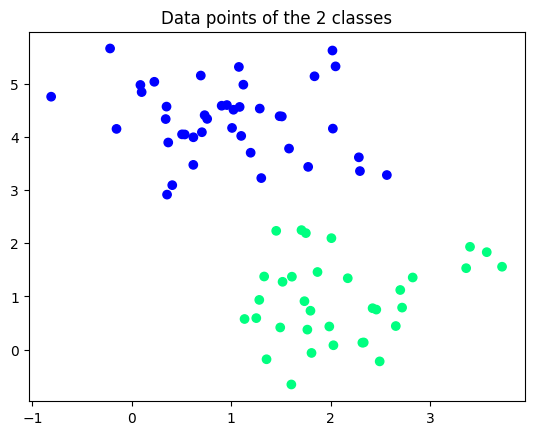

In [6]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_train_pred_slr, cmap='winter')
plt.title('Data points of the 2 classes')
plt.show()

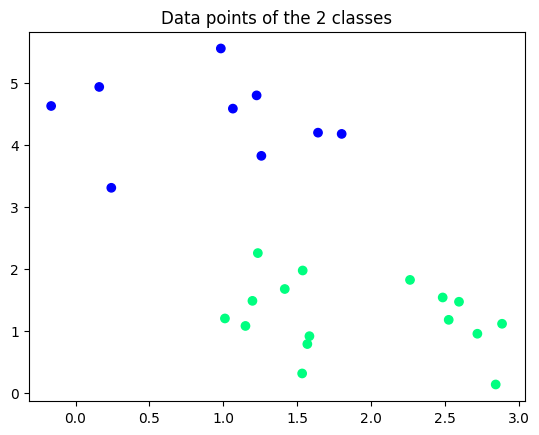

In [7]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_pred_slr, cmap='winter')
plt.title('Data points of the 2 classes')
plt.show()

k_max  6 , e_max  14 , acc_max  1.0


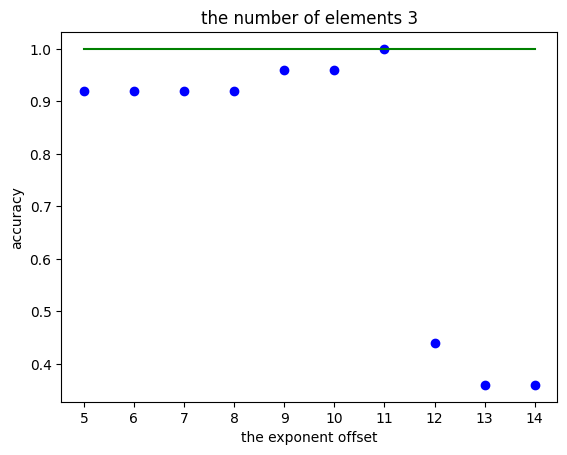

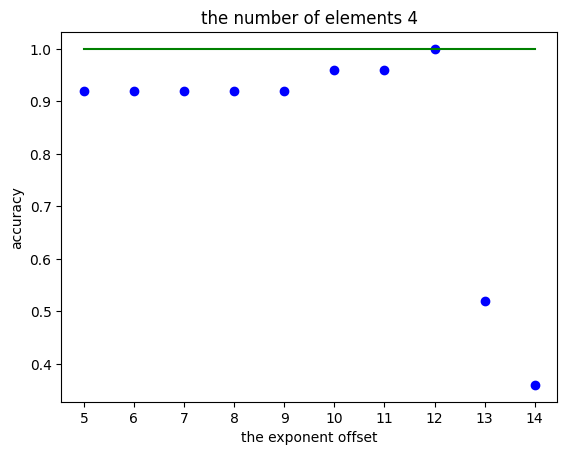

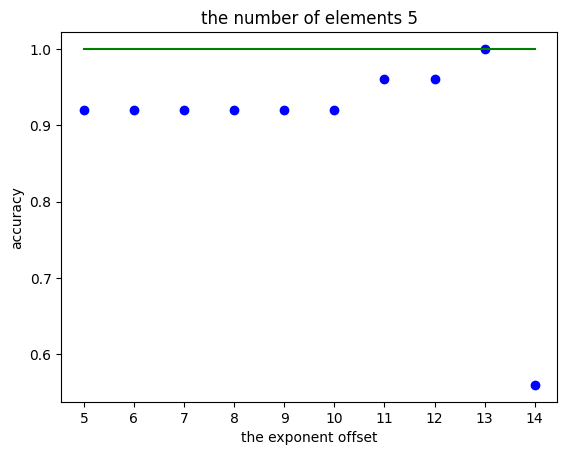

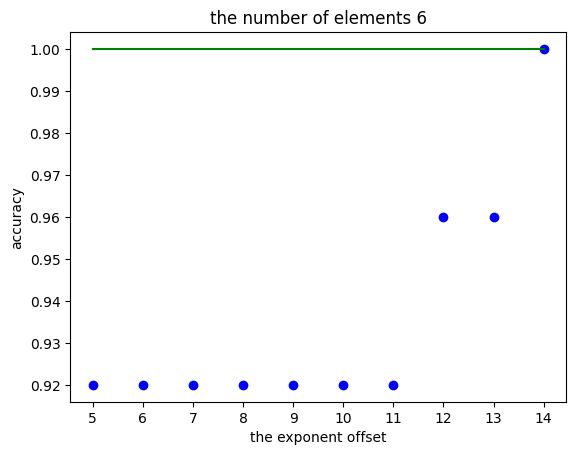

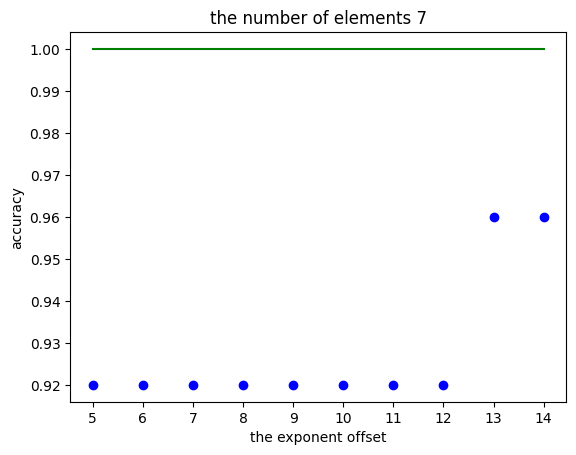

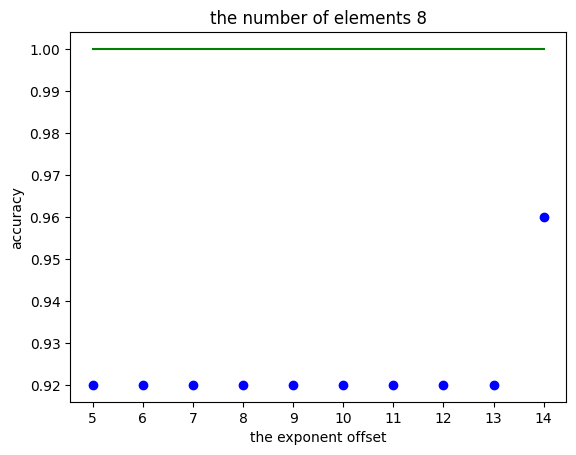

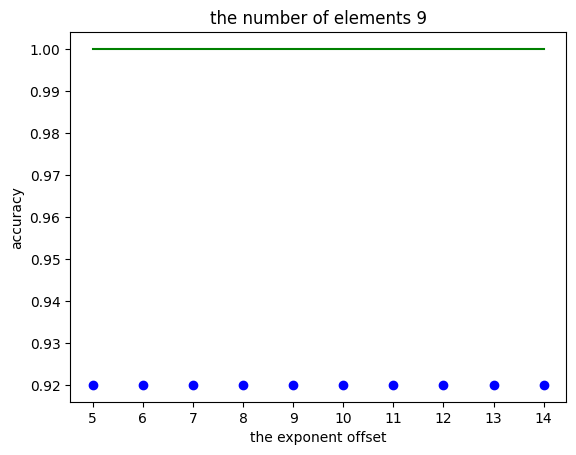

In [8]:
acc_max = 0
k_max = 0
e_max = 0
list_exponent_offset = list(range(5, 15))

for k in range(3, 10):
  acc = np.zeros(10)
  for i, e in enumerate(list_exponent_offset):
    model = QSVC()
    model.fit(X_train, t_train, client, num_elements=k, exponent_offset=e, xi=1)
    y_pred = model.predict(X_test)
    acc[i] = accuracy_score(t_test, y_pred)
    if acc_max <= acc[i]:
      acc_max = acc[i]
      k_max = k
      e_max = e

  fig = plt.figure()
  ax = fig.add_subplot(111)
  ax.set_title("the number of elements "+ str(k))
#   ax.set_ylim(0.4, 1)
  ax.set_xlabel("the exponent offset")
  ax.set_ylabel("accuracy")
  ax.set_xticks(list_exponent_offset)
  ax.scatter(list_exponent_offset, acc, c ='blue')
  ax.plot(list_exponent_offset, np.full(10, acc_sc), c='green')

print("k_max ", k_max, ", e_max ", e_max, ", acc_max ", acc_max)

In [9]:
qsvc = QSVC()
qsvc.fit(X_train, t_train, client, num_elements=k_max, exponent_offset=e_max, xi=1)

# 作成したモデルから予測(学習用、検証用モデル使用)
y_train_pred_qlr = qsvc.predict(X_train)
y_test_pred_qlr = qsvc.predict(X_test)

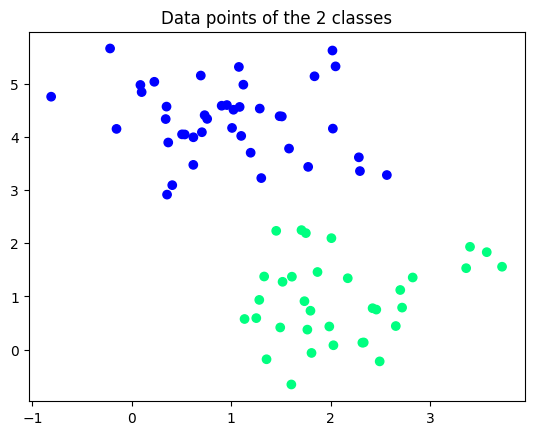

In [10]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_train_pred_qlr, cmap='winter')
plt.title('Data points of the 2 classes')
plt.show()

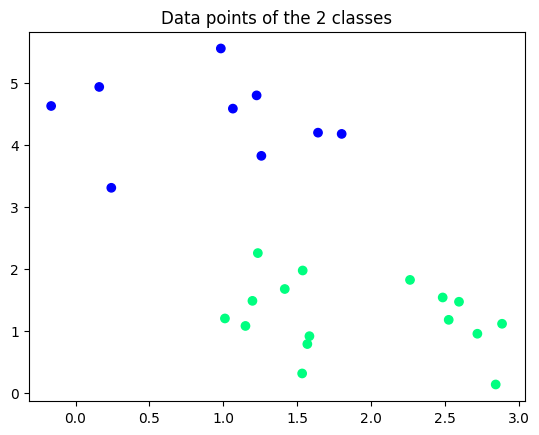

In [11]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_pred_qlr, cmap='winter')
plt.title('Data points of the 2 classes')
plt.show()